## **AMR Interpolation**

Import relevant libraries:

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import struct

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

#### Data reading/formatting

In [10]:
acData = np.empty((4608,2,8,8,8))
bData = np.empty((4608,1,8,8,8))


with open("data.raw", "rb") as file:
    for n in range(4608):
        for k in range(8):
            for j in range(8):
                for i in range(8):
                    acData[n,0,i,j,k] = struct.unpack('<f', file.read(4))[0]         

        for k in range(8):
            for j in range(8):
                for i in range(8):
                    acData[n,1,i,j,k] = struct.unpack('<f', file.read(4))[0]

        for k in range(8):
            for j in range(8):
                for i in range(8):
                    bData[n,0,i,j,k] = struct.unpack('<f', file.read(4))[0]


X_full = torch.from_numpy(acData).float()
print(torch.mean(X_full))
print(torch.std(X_full))
y_full = torch.from_numpy(bData).float()
print(torch.mean(y_full))
print(torch.std(y_full))

class CombustionData(Dataset):
    def __init__(self, X_full, y_full):
        super().__init__()
        X_full = X_full
        print(X_full.shape)
        y_full = y_full
        print(y_full.shape)
    
    def __len__(self):
        return len(X_full)

    def __getitem__(self, idx):
        input = X_full[idx]
        output = y_full[idx]
        # sample = {'input': input, 'output': output}
        return input, output

tensor(-9.5058e+09)
tensor(1.8497e+09)
tensor(-9.5055e+09)
tensor(1.8472e+09)


#### Define Models

In [11]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size=3, stride=stride, padding = 1)
        self.bn1 = nn.BatchNorm3d(out_channels)
        self.relu = nn.LeakyReLU()
        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size=3, stride=stride, padding = 1)
        self.bn2 = nn.BatchNorm3d(out_channels)

        self.shortcut = nn.Sequential() # skip connection
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv3d(in_channels, out_channels, kernel_size=1, stride=stride, padding=0),
                nn.BatchNorm3d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.initial_conv = nn.Conv3d(2, 64, kernel_size=3, stride=1, padding=1)
        self.residual_blocks = nn.Sequential(*[ResidualBlock(64, 64) for _ in range(16)])
        self.final_conv = nn.Conv3d(64, 1, kernel_size=3, stride=1, padding=1)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.initial_conv(x)
        x = self.residual_blocks(x)
        x = self.final_conv(x)
        x = self.tanh(x)
        return x

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.initial_conv = nn.Conv3d(1, 64, kernel_size=3, stride=1, padding=1)
        self.residual_blocks = nn.Sequential(*[ResidualBlock(64, 64) for _ in range(16)])
        self.final_conv = nn.Conv3d(64, 1, kernel_size=3, stride=1, padding=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.initial_conv(x)
        x = self.residual_blocks(x)
        x = self.final_conv(x)
        return self.sigmoid(x)        

#### Hyperparameters

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on", device)
lr = 2e-4
beta1 = 0.5
batch_size = 32
epochs = 250

Running on cuda


#### Initializations

In [19]:
transform = transforms.Normalize(torch.mean(X_full), torch.std(X_full))
X_full = transform(X_full)
y_full = transform(y_full)
dataset = CombustionData(X_full, y_full)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

gen = Generator().to(device)
disc = Discriminator().to(device)

opt_disc = optim.Adam(disc.parameters(), lr=lr, betas=(beta1, 0.999))
opt_gen = optim.Adam(gen.parameters(), lr=lr, betas=(beta1, 0.999))
criterion = nn.BCEWithLogitsLoss()

torch.Size([4608, 2, 8, 8, 8])
torch.Size([4608, 1, 8, 8, 8])


#### Train function

In [20]:
def train(generator, discriminator, opt_gen, opt_disc, data_loader, epochs):
    
    # store losses
    d_losses = []
    g_losses = []
    
    for epoch in range(epochs):
        for i, (inputs, targets) in enumerate(data_loader):

            inputs = inputs.to(device)
            targets = targets.to(device)
            
            # Train discriminator
            opt_disc.zero_grad()

            real_data = targets
            #real_data = torch.cat((inputs, targets), dim=1).to(device)
            real_labels = torch.empty(size=(real_data.size(0), 1, 8, 8, 8)).uniform_(0.7, 1).to(device)
            #real_labels = torch.ones(real_data.size(0), 1, 8, 8, 8).to(device)
            fake_data = generator(inputs)
            #fake_data = torch.cat((inputs, generator(inputs)), dim=1).to(device)
            fake_labels = torch.empty(size=(real_data.size(0), 1, 8, 8, 8)).uniform_(0, 0.3).to(device)
            #fake_labels = torch.zeros(real_data.size(0), 1, 8, 8, 8).to(device)

            output_real = discriminator(real_data)
            loss_real = criterion(output_real, real_labels)

            output_fake = discriminator(fake_data.detach())
            loss_fake = criterion(output_fake, fake_labels)

            loss_d = loss_real + loss_fake
            loss_d.backward()
            opt_disc.step()

            # Train generator
            opt_gen.zero_grad()

            output_fake = discriminator(fake_data)
            loss_g = criterion(output_fake, real_labels)

            loss_g.backward()
            opt_gen.step()

        d_losses.append(loss_d.item())
        g_losses.append(loss_g.item())

        print(f'Epoch [{epoch+1}/{epochs}], Loss D: {loss_d.item()}, Loss G: {loss_g.item()}')
        
    return d_losses, g_losses

#### Learn model

In [21]:
d_losses, g_losses = train(gen, disc, opt_gen, opt_disc, loader, epochs)

Epoch [1/250], Loss D: 1.2537764310836792, Loss G: 0.6895157098770142
Epoch [2/250], Loss D: 1.3859189748764038, Loss G: 0.6900774836540222
Epoch [3/250], Loss D: 1.3862825632095337, Loss G: 0.6931316256523132
Epoch [4/250], Loss D: 1.386284351348877, Loss G: 0.6931008100509644
Epoch [5/250], Loss D: 1.3863258361816406, Loss G: 0.6930575370788574
Epoch [6/250], Loss D: 1.386286735534668, Loss G: 0.6930804252624512
Epoch [7/250], Loss D: 1.3862826824188232, Loss G: 0.6929413080215454
Epoch [8/250], Loss D: 1.3862950801849365, Loss G: 0.6931334733963013
Epoch [9/250], Loss D: 1.3862957954406738, Loss G: 0.6931332349777222
Epoch [10/250], Loss D: 1.3862941265106201, Loss G: 0.6931353211402893
Epoch [11/250], Loss D: 1.386293649673462, Loss G: 0.693135678768158
Epoch [12/250], Loss D: 1.386296033859253, Loss G: 0.6931352019309998
Epoch [13/250], Loss D: 1.3862967491149902, Loss G: 0.6931352615356445
Epoch [14/250], Loss D: 1.3862969875335693, Loss G: 0.6931365132331848
Epoch [15/250], Loss

#### Plot losses

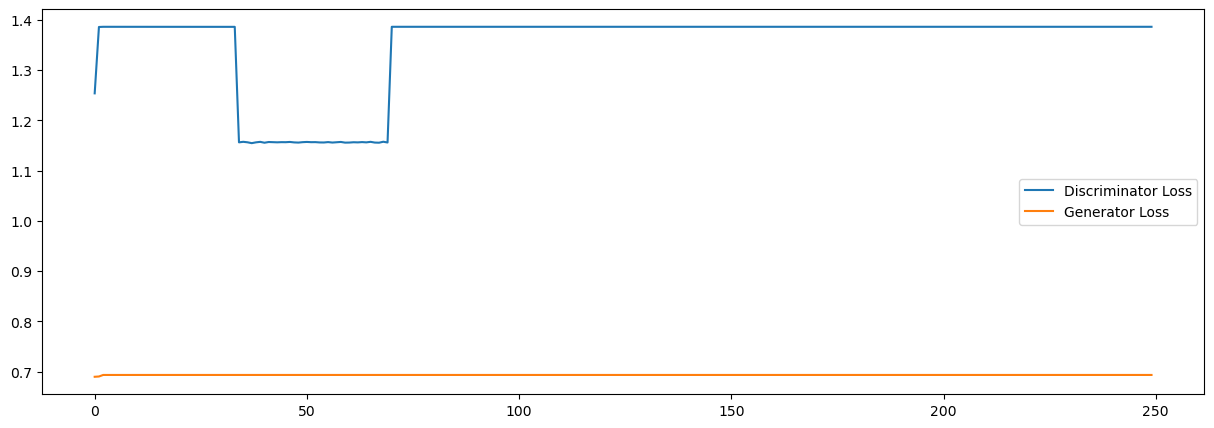

In [22]:
plt.figure(figsize = (15,5))
plt.plot(range(epochs), d_losses, label='Discriminator Loss')
plt.plot(range(epochs), g_losses, label='Generator Loss')
plt.legend()